In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class NAFBlock(nn.Module):
    def __init__(self, c):
        super().__init__()

        self.norm = nn.GroupNorm(1, c) 
        
        # Expanding channels, applying depthwise convolution, then using SimpleGate
        self.conv1 = nn.Conv2d(c, c * 2, 1)
        self.conv2 = nn.Conv2d(c * 2, c * 2, 3, padding=1, groups=c * 2)
        self.sg = SimpleGate()
        
        # Simplified Channel Attention (SCA)
        self.sca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(c, c, 1)
        )
        
        # Compressing back to original channels
        self.conv3 = nn.Conv2d(c, c, 1)

    def forward(self, x):
        identity = x
        x = self.norm(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.sg(x)
        
        # Applying Simplified Channel Attention
        x = x * self.sca(x)
        x = self.conv3(x)
        
        return identity + x

# The NAF-Powered Super Resolution Network
class FastSRNet(nn.Module):
    def __init__(self, upscale_factor=2):
        super().__init__()
        # Entry layer: 1 input channel -> 96 feature channels
        self.entry = nn.Conv2d(1, 64, 3, padding=1) 
        
        # 12 Deep NAFBlocks operating on 96 channels
        self.res_blocks = nn.Sequential(
            *[NAFBlock(64) for _ in range(6)] 
        )
        
        # THE FIX: Upsample layer now correctly accepts 96 channels
        self.upsample = nn.Sequential(
            nn.Conv2d(64, 64 * (upscale_factor ** 2), 3, padding=1),
            nn.PixelShuffle(upscale_factor)
        )
        
        # THE FIX: Exit layer now correctly accepts 96 channels -> 1 output channel
        self.exit = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x):
        x = self.entry(x)
        x = x + self.res_blocks(x)
        x = self.upsample(x)
        return torch.sigmoid(self.exit(x))

# #Loss Function with Edge Loss
# class SSIMLoss(nn.Module):
#     def __init__(self, window_size=11, channel=1):
#         super().__init__()
#         self.window_size = window_size
#         self.channel = channel
#         window = self._create_window(window_size, channel)
#         self.register_buffer('window', window)
        
#         # Sobel filters for Edge Loss
#         k_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]).view(1, 1, 3, 3).float() / 4.
#         k_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]).view(1, 1, 3, 3).float() / 4.
#         self.register_buffer('k_x', k_x)
#         self.register_buffer('k_y', k_y)

#     def _gaussian(self, window_size, sigma):
#         gauss = torch.tensor([np.exp(-(x - window_size//2)**2 / (2*sigma**2)) for x in range(window_size)], dtype=torch.float32)
#         return gauss / gauss.sum()

#     def _create_window(self, window_size, channel):
#         _1D_window = self._gaussian(window_size, 1.5).unsqueeze(1)
#         _2D_window = _1D_window.mm(_1D_window.t()).float()
#         window = _2D_window.unsqueeze(0).unsqueeze(0)
#         return window.expand(channel, 1, window_size, window_size).contiguous()

#     def edge_loss(self, pred, target):
#         pred_x = F.conv2d(pred, self.k_x, padding=1)
#         pred_y = F.conv2d(pred, self.k_y, padding=1)
#         target_x = F.conv2d(target, self.k_x, padding=1)
#         target_y = F.conv2d(target, self.k_y, padding=1)
#         return F.l1_loss(pred_x, target_x) + F.l1_loss(pred_y, target_y)

#     def forward(self, pred, target):
#         mu1 = F.conv2d(pred, self.window, padding=self.window_size//2, groups=self.channel)
#         mu2 = F.conv2d(target, self.window, padding=self.window_size//2, groups=self.channel)
#         mu1_sq, mu2_sq, mu1_mu2 = mu1.pow(2), mu2.pow(2), mu1 * mu2

#         sigma1_sq = F.conv2d(pred*pred, self.window, padding=self.window_size//2, groups=self.channel) - mu1_sq
#         sigma2_sq = F.conv2d(target*target, self.window, padding=self.window_size//2, groups=self.channel) - mu2_sq
#         sigma12 = F.conv2d(pred*target, self.window, padding=self.window_size//2, groups=self.channel) - mu1_mu2

#         C1, C2 = 0.01**2, 0.03**2
#         ssim_map = ((2*mu1_mu2 + C1)*(2*sigma12 + C2)) / ((mu1_sq + mu2_sq + C1)*(sigma1_sq + sigma2_sq + C2))
        
#         l1_loss = F.l1_loss(pred, target)
#         ssim_loss = 1 - ssim_map.mean()
#         edge_loss = self.edge_loss(pred, target)
        
#         # New Balance: 70% Base Colors/Structures, 20% Texture Similarity, 10% Razor-Sharp Edges
#         return 0.7 * l1_loss + 0.2 * ssim_loss + 0.1 * edge_loss
# # --- THE LEADERBOARD SNIPER LOSS ---
class CombinedMetricLoss(nn.Module):
    def __init__(self, window_size=11, channel=1):
        super().__init__()
        self.window_size = window_size
        self.channel = channel
        window = self._create_window(window_size, channel)
        self.register_buffer('window', window)

    def _gaussian(self, window_size, sigma):
        gauss = torch.tensor([np.exp(-(x - window_size//2)**2 / (2*sigma**2)) for x in range(window_size)], dtype=torch.float32)
        return gauss / gauss.sum()

    def _create_window(self, window_size, channel):
        _1D_window = self._gaussian(window_size, 1.5).unsqueeze(1)
        _2D_window = _1D_window.mm(_1D_window.t()).float()
        window = _2D_window.unsqueeze(0).unsqueeze(0)
        return window.expand(channel, 1, window_size, window_size).contiguous()

    def forward(self, pred, target):
        # 1. Calculate the SSIM Map
        mu1 = F.conv2d(pred, self.window, padding=self.window_size//2, groups=self.channel)
        mu2 = F.conv2d(target, self.window, padding=self.window_size//2, groups=self.channel)
        mu1_sq, mu2_sq, mu1_mu2 = mu1.pow(2), mu2.pow(2), mu1 * mu2

        sigma1_sq = F.conv2d(pred*pred, self.window, padding=self.window_size//2, groups=self.channel) - mu1_sq
        sigma2_sq = F.conv2d(target*target, self.window, padding=self.window_size//2, groups=self.channel) - mu2_sq
        sigma12 = F.conv2d(pred*target, self.window, padding=self.window_size//2, groups=self.channel) - mu1_mu2

        C1, C2 = 0.01**2, 0.03**2
        ssim_map = ((2*mu1_mu2 + C1)*(2*sigma12 + C2)) / ((mu1_sq + mu2_sq + C1)*(sigma1_sq + sigma2_sq + C2))
        
        # 2. Extract the two metrics the leaderboard cares about
        ssim_loss = 1 - ssim_map.mean()
        
        # We use MSE (L2) instead of L1 here because PSNR is mathematically derived from MSE
        mse_loss = F.mse_loss(pred, target)
        
        # 3. The Grandmaster Balance: 
        # MSE numbers are naturally very tiny (e.g., 0.005), and SSIM loss is larger (e.g., 0.1).
        # We multiply MSE by a factor to ensure the optimizer cares about both equally!
        return (10.0 * mse_loss) + ssim_loss

In [18]:
import os
import random
import numpy as np
import torch
from torch.utils.data import Dataset

class FastPatchDataset(Dataset):
    def __init__(self, is_train=True, lr_patch_size=64, upscale_factor=2):
        self.noisy_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/train/NoisyLR"
        self.clean_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/train/GT"
        self.files = sorted([f for f in os.listdir(self.noisy_dir) if f.endswith(".npy")])
        self.is_train = is_train
        self.lr_patch_size = lr_patch_size
        self.scale = upscale_factor

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]
        
        # Loading raw arrays
        noisy = np.load(os.path.join(self.noisy_dir, name)).astype(np.float32)
        clean = np.load(os.path.join(self.clean_dir, name)).astype(np.float32)
        
        # Normalizing
        noisy = np.clip(noisy, 0, 1)
        clean = np.clip(clean, 0, 1)

        if self.is_train:
            h, w = noisy.shape
            
            # Random Cropping
            x = random.randint(0, w - self.lr_patch_size)
            y = random.randint(0, h - self.lr_patch_size)
            
            noisy = noisy[y : y + self.lr_patch_size, x : x + self.lr_patch_size]
            clean = clean[y * self.scale : (y + self.lr_patch_size) * self.scale, 
                          x * self.scale : (x + self.lr_patch_size) * self.scale]

            # Advanced Augmentation
            # Random Flips
            if random.random() > 0.5:
                noisy = np.flip(noisy, axis=1) 
                clean = np.flip(clean, axis=1)
            if random.random() > 0.5:
                noisy = np.flip(noisy, axis=0) 
                clean = np.flip(clean, axis=0)
            
            # Random 90-degree Rotations
            if random.random() > 0.5:
                k = random.randint(1, 3) # Rotate 90, 180, or 270 degrees
                noisy = np.rot90(noisy, k)
                clean = np.rot90(clean, k)


        noisy = np.expand_dims(noisy.copy(), 0)
        clean = np.expand_dims(clean.copy(), 0)

        return torch.tensor(noisy), torch.tensor(clean)


dataset = FastPatchDataset()
x, y = dataset[0]
print(f"Optimized Dataset ready. LR shape: {x.shape}, HR shape: {y.shape}")

Optimized Dataset ready. LR shape: torch.Size([1, 64, 64]), HR shape: torch.Size([1, 128, 128])


In [19]:
# from torch.utils.data import DataLoader
# from torch.amp import GradScaler, autocast
# import torch

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Training on: {device}")

# model = FastSRNet(upscale_factor=2).to(device)
# criterion = SSIMLoss().to(device)


# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

# EPOCHS = 100

# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# loader = DataLoader(
#     FastPatchDataset(is_train=True),
#     batch_size=64,            
#     shuffle=True,
#     num_workers=4,           
#     pin_memory=True,         
#     persistent_workers=True  
# )

# scaler = GradScaler('cuda')

# for epoch in range(EPOCHS):
#     model.train()
#     total_loss = 0

#     for noisy, clean in loader:
#         noisy = noisy.to(device, non_blocking=True)
#         clean = clean.to(device, non_blocking=True)

#         optimizer.zero_grad()

#         with autocast('cuda'):
#             pred = model(noisy)
            
#         loss = criterion(pred.float(), clean.float())

#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()

#         total_loss += loss.item()

#     avg_loss = total_loss / len(loader)
    
#     current_lr = optimizer.param_groups[0]['lr']
#     print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.5f} | LR: {current_lr:.6f}")
    
#     scheduler.step()
    
# torch.save(model.state_dict(), "/kaggle/working/restoration_model.pth")
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training Leaderboard Sniper on: {device}")

# 1. The massive 96-channel model (Starting Fresh!)
model = FastSRNet(upscale_factor=2).to(device)

# 2. The Custom PSNR/SSIM Loss Function
criterion = CombinedMetricLoss().to(device)

# 3. Healthy starting learning rate
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

EPOCHS = 70 

# Smoothly drops the LR to zero over 150 epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

loader = DataLoader(
    FastPatchDataset(is_train=True),
    batch_size=32,            
    shuffle=True,
    num_workers=4,           
    pin_memory=True,         
    persistent_workers=True  
)

scaler = GradScaler('cuda')

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for noisy, clean in loader:
        noisy = noisy.to(device, non_blocking=True)
        clean = clean.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast('cuda'):
            pred = model(noisy)
            
        # Safe 32-bit math for the combined loss
        loss = criterion(pred.float(), clean.float())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | Combined Loss: {avg_loss:.5f} | LR: {current_lr:.6f}")
    
    scheduler.step()
    
# Save the ultimate weights!
torch.save(model.state_dict(), "/kaggle/working/restoration_model.pth")

Training Leaderboard Sniper on: cuda
Epoch 001/70 | Combined Loss: 0.54341 | LR: 0.000500
Epoch 002/70 | Combined Loss: 0.35316 | LR: 0.000500
Epoch 003/70 | Combined Loss: 0.30907 | LR: 0.000499
Epoch 004/70 | Combined Loss: 0.28973 | LR: 0.000498
Epoch 005/70 | Combined Loss: 0.28222 | LR: 0.000496
Epoch 006/70 | Combined Loss: 0.27470 | LR: 0.000494
Epoch 007/70 | Combined Loss: 0.27298 | LR: 0.000491
Epoch 008/70 | Combined Loss: 0.27288 | LR: 0.000488
Epoch 009/70 | Combined Loss: 0.26762 | LR: 0.000484
Epoch 010/70 | Combined Loss: 0.26845 | LR: 0.000480
Epoch 011/70 | Combined Loss: 0.26573 | LR: 0.000475
Epoch 012/70 | Combined Loss: 0.26512 | LR: 0.000470
Epoch 013/70 | Combined Loss: 0.26397 | LR: 0.000465
Epoch 014/70 | Combined Loss: 0.26377 | LR: 0.000459
Epoch 015/70 | Combined Loss: 0.26059 | LR: 0.000452
Epoch 016/70 | Combined Loss: 0.25950 | LR: 0.000446
Epoch 017/70 | Combined Loss: 0.26090 | LR: 0.000438
Epoch 018/70 | Combined Loss: 0.25897 | LR: 0.000431
Epoch 019

In [20]:
import os
import numpy as np
import torch
from torch.amp import autocast


test_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/test/NoisyLR"
submission_dir = "/kaggle/working/submission/"
os.makedirs(submission_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running inference on: {device}")

# Loading the trained NAFNet model
model = FastSRNet(upscale_factor=2).to(device)
model.load_state_dict(torch.load("/kaggle/working/restoration_model.pth"))
model.eval()

files = sorted([f for f in os.listdir(test_dir) if f.endswith(".npy")])
print(f"Found {len(files)} files! Starting Test-Time Augmentation (TTA) inference...")

for idx, name in enumerate(files):
    path = os.path.join(test_dir, name)

    # Loading and normalizing
    img = np.load(path).astype(np.float32)
    img = np.clip(img, 0, 1)
    
    # Shape: (1, 1, 128, 128)
    img_tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        with autocast('cuda'):
            # The Full x8 TTA Hack
            # 1. Base orientations
            p1 = model(img_tensor)
            p2 = torch.flip(model(torch.flip(img_tensor, dims=[3])), dims=[3]) 
            p3 = torch.flip(model(torch.flip(img_tensor, dims=[2])), dims=[2]) 
            p4 = torch.flip(model(torch.flip(img_tensor, dims=[2, 3])), dims=[2, 3]) 
            
            # 2. Rotated orientations (90 degrees)
            img_rot = torch.rot90(img_tensor, 1, [2, 3])
            
            p5 = torch.rot90(model(img_rot), -1, [2, 3])
            p6 = torch.rot90(torch.flip(model(torch.flip(img_rot, dims=[3])), dims=[3]), -1, [2, 3])
            p7 = torch.rot90(torch.flip(model(torch.flip(img_rot, dims=[2])), dims=[2]), -1, [2, 3])
            p8 = torch.rot90(torch.flip(model(torch.flip(img_rot, dims=[2, 3])), dims=[2, 3]), -1, [2, 3])
            
            # Average all 8 predictions
            pred = (p1 + p2 + p3 + p4 + p5 + p6 + p7 + p8) / 8.0

    # Moving back to CPU and formatting for saving
    pred = pred.squeeze().cpu().numpy()
    pred = np.clip(pred, 0, 1).astype(np.float32)

    # Saving to submission folder
    np.save(os.path.join(submission_dir, name), pred)
    
    if (idx + 1) % 50 == 0:
        print(f"Processed {idx + 1}/200 files...")

print(f"BOOM! Inference complete. All 200 files saved to {submission_dir}")

Running inference on: cuda
Found 200 files! Starting Test-Time Augmentation (TTA) inference...
Processed 50/200 files...
Processed 100/200 files...
Processed 150/200 files...
Processed 200/200 files...
BOOM! Inference complete. All 200 files saved to /kaggle/working/submission/


In [10]:
import shutil
shutil.make_archive("/kaggle/working/final_submission", 'zip', "/kaggle/working/submission/")
print("Zip file created successfully! Ready to download and submit.")

Zip file created successfully! Ready to download and submit.


In [21]:
'''import os
import numpy as np
import torch
from torch.amp import autocast

test_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/test"
submission_dir = "/kaggle/working/submission/"

os.makedirs(submission_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initialize the same FastSRNet model and load the trained weights
model = FastSRNet(upscale_factor=2).to(device)
model.load_state_dict(torch.load("/kaggle/working/restoration_model.pth"))
model.eval()

if not os.path.exists(test_dir):
    print(f"Error: Could not find {test_dir}. Check the exact folder path!")
else:
    files = sorted([f for f in os.listdir(test_dir) if f.endswith(".npy")])
    print(f"Found {len(files)} files for inference. Starting...")

    for idx, name in enumerate(files):
        path = os.path.join(test_dir, name)

        # 2. Load the raw 128x128 numpy array (No cv2.resize!)
        img = np.load(path).astype(np.float32)
        img = np.clip(img, 0, 1)

        # 3. Add batch and channel dimensions -> shape: (1, 1, 128, 128)
        img_tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            with autocast('cuda'):
                # 4. Model naturally outputs the upscaled 256x256 image
                pred = model(img_tensor)

        # 5. Move back to CPU, strip extra dimensions, and format as numpy array
        pred = pred.squeeze().cpu().numpy()
        pred = np.clip(pred, 0, 1).astype(np.float32)

        np.save(
            os.path.join(submission_dir, name),
            pred
        )
        
    print(f"Inference complete! All upscaled 256x256 files saved to {submission_dir}")'''

'import os\nimport numpy as np\nimport torch\nfrom torch.amp import autocast\n\ntest_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/test"\nsubmission_dir = "/kaggle/working/submission/"\n\nos.makedirs(submission_dir, exist_ok=True)\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\n# 1. Initialize the same FastSRNet model and load the trained weights\nmodel = FastSRNet(upscale_factor=2).to(device)\nmodel.load_state_dict(torch.load("/kaggle/working/restoration_model.pth"))\nmodel.eval()\n\nif not os.path.exists(test_dir):\n    print(f"Error: Could not find {test_dir}. Check the exact folder path!")\nelse:\n    files = sorted([f for f in os.listdir(test_dir) if f.endswith(".npy")])\n    print(f"Found {len(files)} files for inference. Starting...")\n\n    for idx, name in enumerate(files):\n        path = os.path.join(test_dir, name)\n\n        # 2. Load the raw 128x128 numpy array (No cv2.resize!)\n        img = np.load(path).astype(np.float32

In [61]:
import os
import numpy as np
import base64
import pandas as pd
from io import BytesIO

submission_dir = "/kaggle/working/submission"

rows = []

files = sorted([f for f in os.listdir(submission_dir) if f.endswith(".npy")])

for idx, file in enumerate(files, start=1):

    path = os.path.join(submission_dir, file)

    # load numpy array
    arr = np.load(path)

    # convert array to bytes
    buffer = BytesIO()
    np.save(buffer, arr)

    encoded = base64.b64encode(buffer.getvalue()).decode()

    rows.append({
        "id": idx,
        "npy_base64": encoded
    })

df = pd.DataFrame(rows)

df.to_csv("/kaggle/working/submission.csv", index=False)

print("Submission created with", len(df), "rows")


Submission created with 200 rows


In [59]:
'''import os
test_path = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/test/NoisyLR"

# Let's see exactly what is sitting inside this folder
files = os.listdir(test_path)
print(f"Total files found: {len(files)}")

if len(files) > 0:
    print(f"Here are the first 5 files: {files[:5]}")'''

Total files found: 200
Here are the first 5 files: ['000115.npy', '000088.npy', '000143.npy', '000071.npy', '000107.npy']


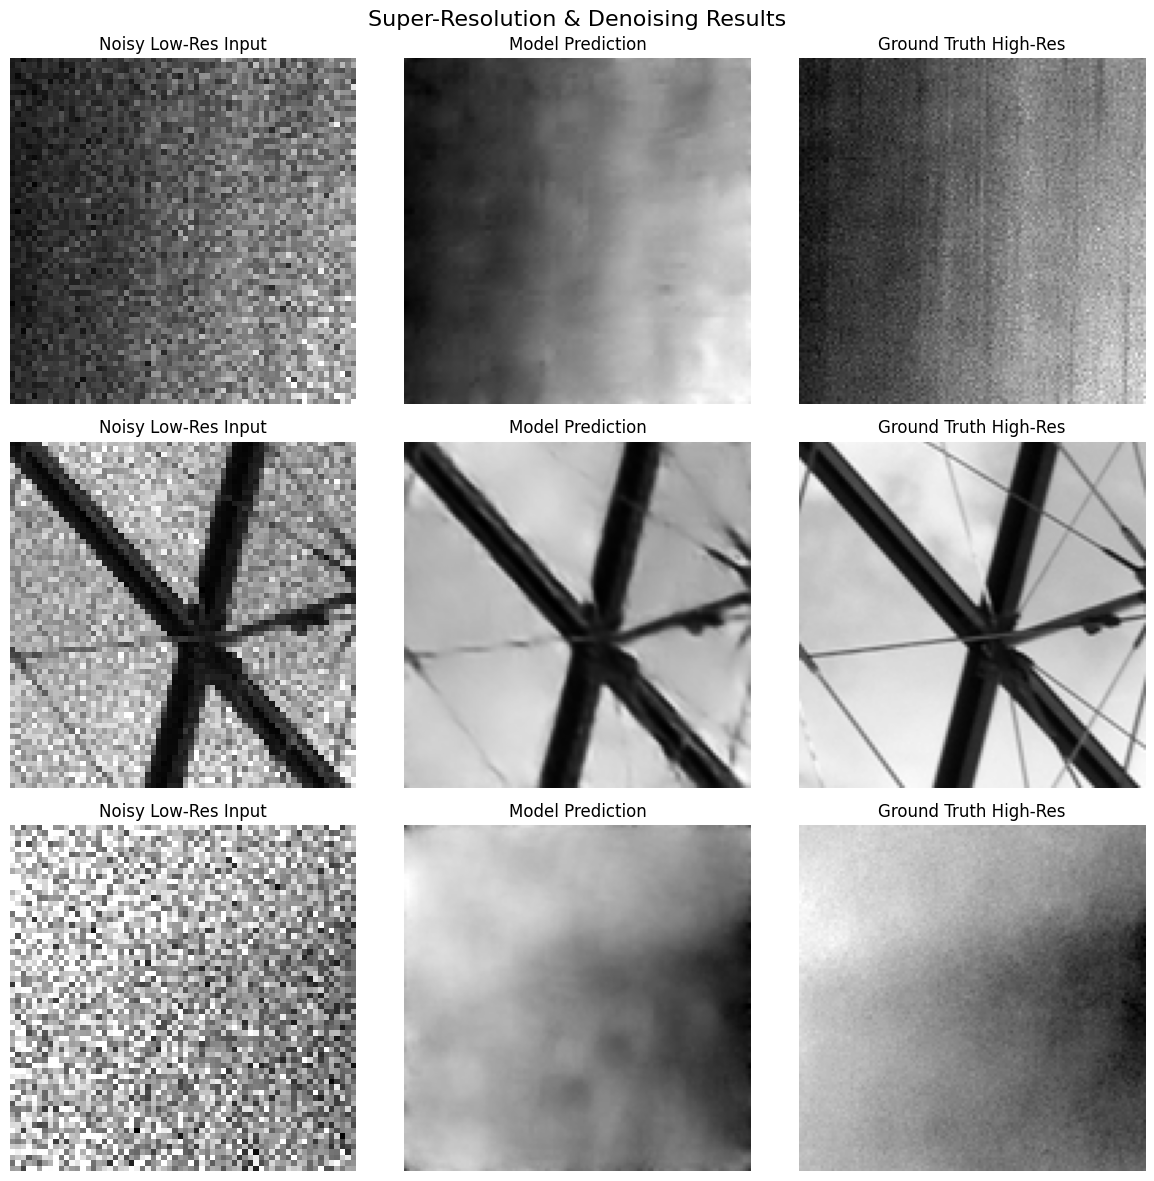

In [25]:
'''import matplotlib.pyplot as plt
import torch

# Make sure the model is in evaluation mode so it doesn't compute gradients
model.eval()

# Grab one single batch of data from your loader
data_iterator = iter(loader)
noisy_imgs, clean_imgs = next(data_iterator)

# Move the noisy images to the GPU and get the model's predictions
noisy_imgs = noisy_imgs.to(device)
with torch.no_grad():
    # Model naturally upscales the 128x128 input to 256x256
    preds = model(noisy_imgs)

# Move everything back to the CPU for plotting
noisy_imgs = noisy_imgs.cpu()
preds = preds.cpu()
clean_imgs = clean_imgs.cpu()

# Choose how many images you want to look at (let's do 3)
num_images = 3

fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
fig.suptitle('Super-Resolution & Denoising Results', fontsize=16)

for i in range(num_images):
    # 1. Plot the Noisy Low-Res Input (128x128)
    ax = axes[i, 0]
    ax.imshow(noisy_imgs[i].squeeze().numpy(), cmap='gray')
    ax.set_title('Noisy Low-Res Input')
    ax.axis('off')
    
    # 2. Plot the Model's Prediction (256x256)
    ax = axes[i, 1]
    ax.imshow(preds[i].squeeze().numpy(), cmap='gray')
    ax.set_title('Model Prediction')
    ax.axis('off')
    
    # 3. Plot the Clean Ground Truth (256x256)
    ax = axes[i, 2]
    ax.imshow(clean_imgs[i].squeeze().numpy(), cmap='gray')
    ax.set_title('Ground Truth High-Res')
    ax.axis('off')

plt.tight_layout()
plt.show()
'''
